Nombres y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3


# Grafos en la vida real

En esta práctica vamos a, usando los conocimientos sobre grafos aprendidos en las prácticas anteriores, crear grafos y explorlos usando datos de la vida real. Para la obtención de estos datos, vamos a usar la librería ``PytorchGeometric``. Esta librería está diseñada para desarrollar y entrenar redes neuronales. Esta librería maneja datos estructurados en forma de grafos, es por eso que esta librería es perfecta para esta práctica.

Vamos ahora a importar todas las librerías que vamos a usar en esta práctica:

In [41]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown
from gensim.models import Word2Vec
import numpy as np
from sklearn.decomposition import PCA

## 1. Node2vec

`Node2vec` es básicamente un algoritmo de aprendizaje automático de representaciones numéricas (embeddings) para cada nodo. La clave está en que, si dos nodos son cercanos sus representaciones también serán cercanas. Para lograr est objetivo, `node2vec` **no** realiza un camino aleatorio (**random walk**), si no que realiza un camino sesgado que controla si el recorrido se mantiene cerca o explora más lejos

### 1.1 Embeddings y word2vec

Una incrustación (o embedding) de un nodo es una representación numérica que resume su papel dentro del grafo. Estas incrustaciones tienes distinitas utilidades:
- Agrupar nodos por similitud
- Clasificar nodos
- Predicción de enlaces (predecir si dos nodos deberían estar concetados)

Las características de estas incrustaciones tienen bastante en común con `Word2vec` en textos, donde las palabras que suelen aparecer juntas tienen representaciones numéricas cercanas. Además, `node2vec` aplica esa misma lógica en los grafos pero usando _random walks_ y en lugar de frases. 

Los embeddings son muy útiles puesto que nos permiten trabajar con información compleja (como grafos que tengan nodos con muchas conexiones) de forma compacta y fácil, quedándonos solo con lo importante

### 1.2 El algoritmo Node2vec

Este algoritmo es una técnica de aprendizaje de representaciones de diseñada exclusivamente para grafos. El objetivo de este algoritmo es aprender embeddings de los nodos, es decir, convertir cada nodo en una lista de vectores (de ahí el nombre: _node_ -> _vec_) que resuma el papel de ese nodo dentro del grafo. La propiedad fundamental es: si dos nodos están cerca en el grafo, sus respresnetaciones numéricas también lo están. Esta propiedad permite al algoritmo capturar relaciones complejas que no siempre son evidentes.

Para cumplir dichos objetivos, `node2vec` funciona en dos pasos:

**Primer paso**
- Generar caminos aleatorios (_random walk_). Sin embargo, este algoritmo no genera caminos de forma aleatoria al 100%, si no que genera los caminos según dos parámetros: \
   -> p: Controla la probabilidad de volver hacia atrás (regresión al nodo anterior)\
   ->  q: Controla si el camino tiende a explorar nodos más lejanos 

Gracias a estos parámetros, el algoritmo puede implementar estrategias de búsqueda como DFS o BFS. Este primer paso se repite muchas veces desde distintos nodos iniciales, generando así un conjunto de secuencias de nodos

**Segundo paso**
- Aprender los embeddings a partir de los caminos aleatorios generados en el primer paso. Aquí es donde este algoritmo y `word2vec` se relacionan: `node2vec` toma cada camino y lo mira como si fuera una frase (los nodos son palabras y el camino es la oración). Luego, utiliza `Skip-Gram` (variante de `word2vec`). Este algoritmo funciona de la siguiente manera: por cada nodo del camino, se coloca como "nodo central" y se predice que nodos aparecen antes y después dentro de una ventana de tamaño fijo. Como los caminos ya contienen la estructura del grafo, el resultado final es que las instructaciones aprendidas codifican tanto las relaciones locales como las gobales del grafo. De esta forma, cada nodo queda representado por un vector numérico que resume su papel dentro del grafo (posición, función...)

#### 1.2.1 Node2vec (código)

Vamos ahora a explicar los distintos bloques que contiene el `node2vec` explicando cada uno con el objetivo de que se entienda mejor

In [4]:
# Función para realizar una caminata aleatoria en el grafo
def node2vec_walk(G, start_node, walk_length):
    walk = [start_node]
    while len(walk) < walk_length:
        cur_node = walk[-1]
        neighbors = list(G.neighbors(cur_node))
        if len(neighbors) > 0:
            walk.append(np.random.choice(neighbors))  # Selecciona un vecino al azar
        else:
            break
    return walk

##### **BLOQUE 1** 
---
Función que realiza un camino aleatorio por el grafo. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **start_choice**: Nodo desde donde se va a empezar a generar el camino
- **walk_length**: Longitud deseada del camino a generar

Devuelve:
- walk: camino generado
---
**Funcionamiento de la función**
- **walk**: Inicializa el camino desde el nodo de inicio. De momento, el camino es una lista que solo contiene el nodo inicial
- _while_: Bucle que se ejecuta mientras que la longitud del camino sea menor que la deseada
- **cur_node**: Accede al último elemento ([-1]) del camino que se convierte en el nodo actual desde el cuál se va a dar el siguiente paso
- **neighbors**: Obtenemos todos los vecinos del nodo actual
- _if_: Comprueba si el nodo actual tiene al menos un vecino. Si el nodo no tiene vecinos (hoja) salimos del bucle
- **walk.append**: Elegimos un vecino al azar y lo añadimos al camino 

In [5]:
# Función para generar múltiples caminatas aleatorias desde cada nodo del grafo
def generate_walks(G, num_walks, walk_length):
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        np.random.shuffle(nodes)  # Mezcla los nodos para añadir aleatoriedad
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length))  # Genera una caminata aleatoria desde el nodo
    return walks

##### **BLOQUE 2** 
---
Función que genera varios caminos. Recibe como argumentos:
- G: Grafo que se va a recorrer
- num_walks: Número de nodos que se van a generar
- walk_length: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Lista donde se van a guardar todos los caminos que se vayan a generar
- **nodes**: Obtiene todos los nodos del grafo y los guarda en una lista (nodes)
- _for_: Bucle que se ejecuta tantas veces como el número de caminos que le hayamos especificado
- **np.random.shuffle**: Mezcla (shuffle) el orden de los nodos al azar. Este paso es importante ya que nos aseguramos de que los caminos aleatorios no empiecen siempre en el mismo orden (añadimos variedad)
- _for_: Recorre cada nodo del grafo 
- **node2vec_walk**: Corazón de la función. Para cada nodo (aleatorio ya que han sido mezclados) llama a la función `node2vec_walk()` (bloque 1) y genera un camino partienod de este y guarda el camino en la lista `walks` 

In [6]:
# Función principal de Node2Vec
def node2vec(G, dimensions, num_walks, walk_length):
    walks = generate_walks(G, num_walks, walk_length)  # Genera todas las caminatas aleatorias
    walks = [list(map(str, walk)) for walk in walks]  # Convierte los nodos a cadenas para gensim
    # walks: Lista de caminatas aleatorias
    # vector_size=dimensions: Tamaño del vector de embeddings
    # window=5: Tamaño de la ventana de contexto, en nodos seria 5 nodos a la izquierda y 5 nodos a la derecha
    # workers=2: Número de hilos para entrenar el modelo
    model = Word2Vec(walks, vector_size=dimensions, window=5, workers=2)  # Entrena el modelo Word2Vec con las caminatas aleatorias
    return model

##### **BLOQUE 3** 
---
Función principal. Aquí es donde entrenamos el modelo `word2vec` pasándole caminos aleatorios como frases. Recibe como argumentos:
- **G**: Grafo que se va a recorrer
- **dimensions**: Dimensión de los embeddings. Es un número entero que dicta cuántos números va a tener el vector (embedding) que represeneta cada nodo (cuanto más grande, más información tendrán los nodos)
- **num_walks**: Número de caminos que se van a generar partiendo desde cada nodo del grafo
- **walk_length**: Longitud deseada de los caminos a generar

Devuelve:
- walks: caminos generados
---
**Funcionamiento de la función**
- **walk**: Llamamos a la función **generate_walks** para generar caminos aleatorios por el grafo. Luego, se convierte cada nodo de cada camino a un string. Hacemos esto porque `Word2vec` espera que los argumentos sean de tipo "str". Guardamos todo en una lista
- **model**: Crea y entrena el modelo `word2vec` usando los caminos generados como si fueran frases
- **return**: Devuelve ya entrenado. Una vez tenemos el modelo entrenado, podemos obtener los embeddings de cada nodo usando: `model.wv['nodo']`

#### 1.2.1 Node2vec (ejecución)

Ahora que ya hemos implementado y explicado el algoritmo, vamos a ejecutarlo sobre un grafo sintético SBM:

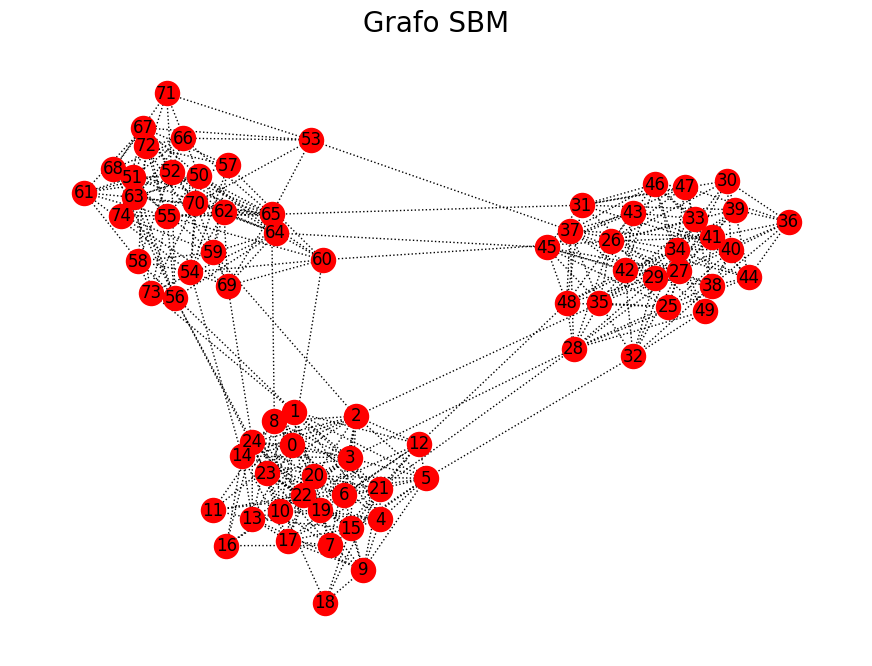

### **Información del grafo**
---

Embedding del nodo **5**:

[-0.8226174  -0.8339627  -0.78305656 -1.2767404   0.14644846 -0.49267852
  0.8521006   0.66790205 -0.87812114 -0.7881876   0.18509565  0.7407289
  0.33222136 -0.23238319 -0.19062172 -0.7218965  -0.24841855  0.10434193
 -1.0564533  -0.39015013]


---

### **Información de los embeddings del grafo**

Embeddings shape: (75, 20)
Embeddings mean: 0.033312276005744934
Embeddings max: 2.596097707748413
Embeddings min: -1.8702274560928345


In [ ]:
# Creamos el grafo con modelo de bloques estocásticos (comunidades)
g = nx.stochastic_block_model([25, 25, 25], [ 
                                            [0.4, 0.01, 0.01],
                                            [0.01, 0.4, 0.01],
                                            [0.01, 0.01, 0.4]], seed=42)
#-------------------------------------------------------------------#

# Ahora que tenemos el grafo creado, vamos primeramente a visualizarlo:
plt.figure(figsize=(11, 8))
plt.title("Grafo SBM", fontsize = 20)
pos = nx.spring_layout(g, seed=99)
nx.draw(g, pos, with_labels=True, node_color='red', edge_color='black', style=":")
plt.axis('off')
plt.show()

#---------------------------------------------------------------------#

# Pasamos ahora con node2vec. La idea es entrenar el modelo word2vec sobre el grafo anteriormente creado
model = node2vec(g, dimensions=20, num_walks=15, walk_length=90)  # Entrena el modelo Node2Vec 
                                                                  # Embeddings: Dimensión de 20
                                                                  # 15 caminos aleatorios a generar con longitud 90 cada uno

#⨪--------------------------------------------------------------------#

# Información a obtener

# Obtiene el embedding de un nodo específico (por ejemplo, nodo 0)
node_id = 5
embedding = model.wv[str(node_id)]
display(Markdown(f'### **Información del grafo**\n---'))
display(Markdown(f'Embedding del nodo **{node_id}**:')) # Embedding del nodo 5
print(embedding)

display(Markdown(f'---'))
display(Markdown(f'### **Información de los embeddings del grafo**'))

# Obtienemos los embeddings de todos los nodos
embeddings = np.array([model.wv[str(node)] for node in g.nodes()])
print(f"Embeddings shape: {embeddings.shape}") # Embeddings shape
print(f"Embeddings mean: {embeddings.mean()}") # Embeddings mean
print(f"Embeddings max: {embeddings.max()}") # Embeddings max
print(f"Embeddings min: {embeddings.min()}") # Embeddings min

#### 1.4 Visualización embeddings

Una vez que hemos aprendido las caracterísitcas de los embeddins, nos planteamos el visualizarlos. El problema está en que no podemos visualizar directamente vectores de altas dimensiones. Para solucionar esto, existen técnicas de reducción de dimensiones como **PCA** o **t-SNE**. Estos métodos se basan en reducir dimensiones de vectores pero manteniendo las distancias y similitudes entre nodos. Es decir, si dos nodos eran parecidos en el espacio original, después de aplicar reducción esta similitud se debe de seguir viendo. 

Algunas librerías como `sklearn` tienen implementadas las técnicas mencionadas, luego vamos a poner un ejemplo aplicando reducción y luego mostrando los embeddings por terminal:

### **PCA**
---

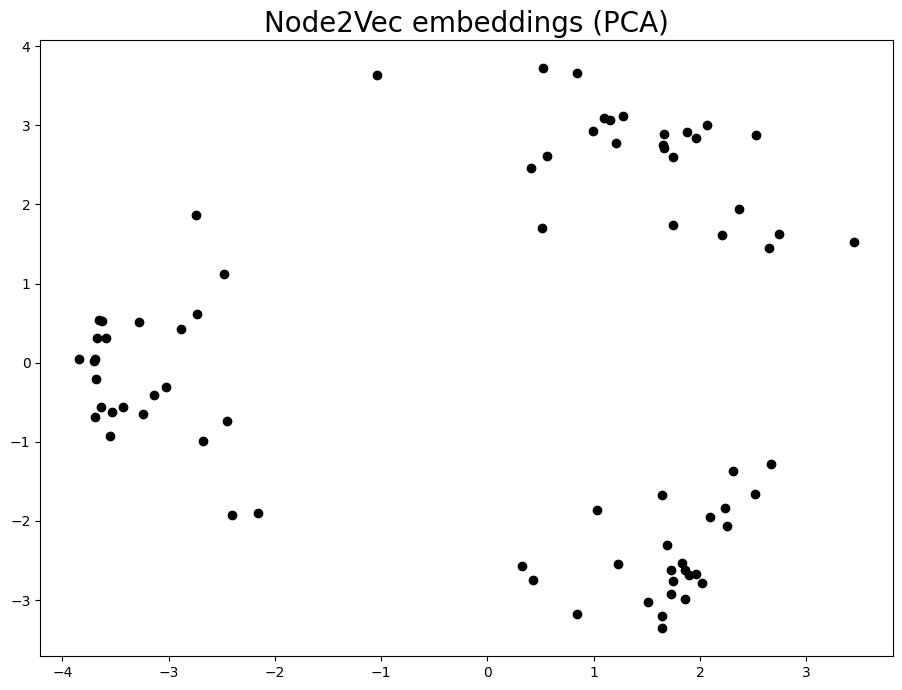

In [47]:
from sklearn.decomposition import PCA

# Vamos a aplicar la técnica PCA

pca = PCA(n_components=2)                          # Creamos la instancia PCA que reduce los embeddings a 2 componentes (n_components = 2)
                                                   # Quire decir que pasamos de las 20 dimensiones originales a solamente 2 (las más relevantes)   
embeddings_pca = pca.fit_transform(embeddings)     # Aplicamos la reducción a los embeddings usando fit_transform() que hace:
                                                   #    # -> fit: calcula ejes principales
                                                   #    # -> transform: proyecta embeddins sobre los ejes calculados

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings

plt.figure(figsize=(11, 8))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], color='black')    # embeddings_pca[:, 0] -> Columna 0 (ejex) de todas las filas
                                                                          # embeddings_pca[:, 1] -> Columna 1 (ejey) de todas las filas
plt.title("Node2Vec embeddings (PCA)", fontsize = 20)
plt.show()

### **PCA (3D)** 
---

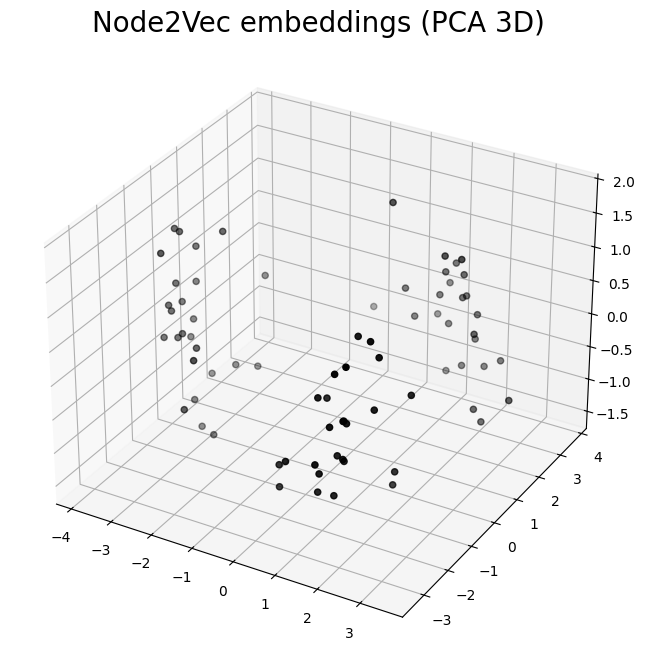

In [55]:
# Vamos a aplicar la técnica PCA pero ahora en 3 dimensiones

pca_3d = PCA(n_components=3)                          # Creamos la instancia PCA que reduce los embeddings a 3 componentes (n_components = 3)
                                                      # Quiere decir que pasamos de las 20 dimensiones originales a solamente 3 (las más relevantes)
embeddings_pca_3d = pca_3d.fit_transform(embeddings)  # Aplicamos la reducción a los embeddings usando fit_transform() que hace:
                                                      #    # -> fit: calcula ejes principales
                                                      #    # -> transform: proyecta embeddings sobre los ejes calculados

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings en 3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')    # Creamos un subplot con proyección 3D

ax.scatter(embeddings_pca_3d[:, 0],           # embeddings_pca_3d[:, 0] -> Columna 0 (eje X) de todas las filas
           embeddings_pca_3d[:, 1],           # embeddings_pca_3d[:, 1] -> Columna 1 (eje Y) de todas las filas
           embeddings_pca_3d[:, 2],           # embeddings_pca_3d[:, 2] -> Columna 2 (eje Z) de todas las filas
           color='black')                     # alpha=0.7 da un poco de transparencia para mejor visualización

ax.set_title("Node2Vec embeddings (PCA 3D)", fontsize=20)

plt.show()

### **t-SNE**
---

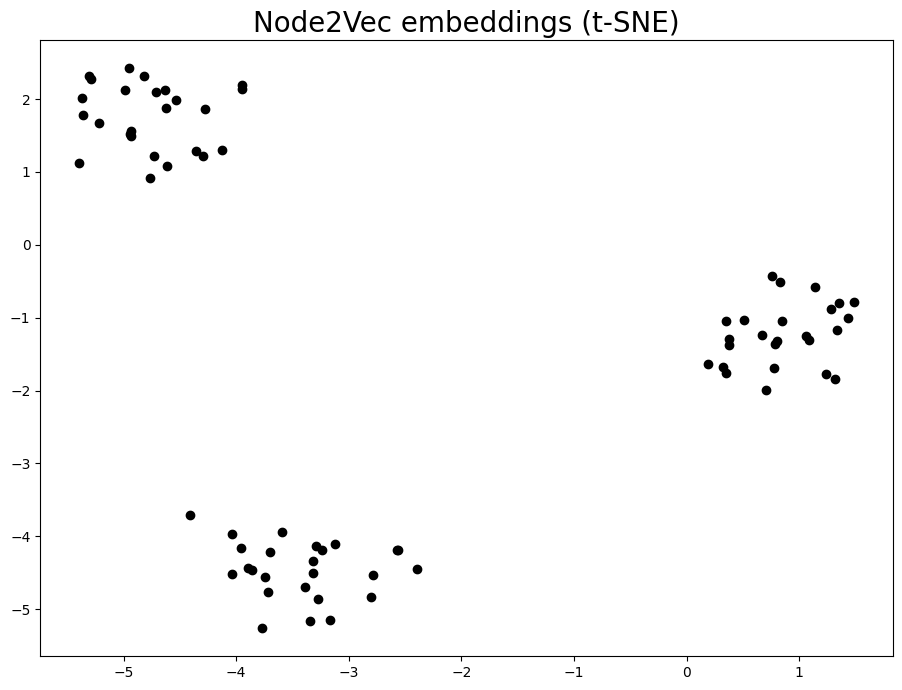

In [56]:
from sklearn.manifold import TSNE

# Vamos a aplicar la técnica t-SNE (t-Distributed Stochastic Neighbor Embedding)

t_sne = TSNE(n_components=2,                           # Reducimos a 2 dimensiones para poder visualizar
            perplexity=30,                            # Perplejidad: balance entre vecinos locales y globales (típico 5-50)
            random_state=42)                          # Semilla fija para que los resultados sean reproducibles

#--------------------------------------------------#

embeddings_tsne = t_sne.fit_transform(embeddings)      # Aplicamos t-SNE a los embeddings
                                                      # fit_transform() hace:
                                                      #    # -> Calcula las probabilidades de similitud entre pares de puntos
                                                      #    # -> Minimiza la divergencia de Kullback-Leibler entre distribuciones
                                                      #    # -> Proyecta los datos en un espacio de baja dimensión

#--------------------------------------------------#

# Una vez realizada la reducción, ya somos capaces de visualizar los embeddings

plt.figure(figsize=(11, 8))
plt.scatter(embeddings_tsne[:, 0],        # embeddings_tsne[:, 0] -> Columna 0 (eje X) de todas las filas
            embeddings_tsne[:, 1],        # embeddings_tsne[:, 1] -> Columna 1 (eje Y) de todas las filas
            color='black')       

plt.title("Node2Vec embeddings (t-SNE)", fontsize=20)
plt.show()


_documentación usada para implementar t-SNE_: \
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

## 2. Ejercicios

### Ejercicio 2

El objetivo de este ejercicio es aplicar el algoritmo `node2vec` estudiado en esta sección a los nodos sintéticos generados en la práctica anterior. Después, visualizamos los embeddings aplicando primero una reducción de dimensiones con PCA o t-SNE. Debido a estos objetivos, vamos a crear una serie de funciones para poder aplicarlas a todos los grafos a estudiar:

In [123]:
# FUNCIONES AUXILIARES
#⨪--------------------#

# FUNCIÓN PCA
def pca(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción PCA

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_pca: Embeddings reducidos a 2 dimensiones

    """
    pca = PCA(n_components=2)                                             
    embeddings_pca = pca.fit_transform(embeddings)   

    return embeddings_pca, "PCA"

# FUNCIÓN T-SNE
def t_sne(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción t-SNE

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_sne: Embeddings reducidos a 2 dimensiones

    """
    tsne = TSNE(n_components=2, perplexity=25, random_state=42)                        
    embeddings_tsne = tsne.fit_transform(embeddings)    

    return embeddings_tsne, "t-SNE"

# ALGORITMO NODE2VEC -> Implementado anteriormente (node2vec())

# FUNCIÓN NODE2VEC + EMBEDDINGS
def n2v(g) -> None:
    """
    Función que ...
    
    """
    model = node2vec(g, dimensions=20, num_walks=15, walk_length=90)
    embeddings = np.array([model.wv[str(node)] for node in g.nodes()]) # embeddings 

    # APLICAMOS REDUCCIÓN A LOS EMBEDDINGS OBTENIDOS
    method = np.random.choice([pca, t_sne])
    embeddings_2d, name = method(embeddings)

    return embeddings_2d, name, embeddings

def properties(embeddings):
    """
    Función que muestra por pantalla propiedades de embeddings
    
    """

    display(Markdown(f'### **Información de los embeddings del grafo**'))
    print(f"Embeddings shape: {embeddings.shape}") 
    print(f"Embeddings mean: {embeddings.mean()}") 
    print(f"Embeddings max: {embeddings.max()}") 
    print(f"Embeddings min: {embeddings.min()}") 
    

# FUNCIÓN DE VISUALIZACIÓN
def visualization(g) -> None:
    """
    Esta función muestra de forma visual un grafo y sus embeddings después de aplicar node2vec. El objetivo es mostrar en una figura 
    dos visualizaciones: en la primera mostramos el grafo original y en la segunda los embeddings del mismo. Además, debajo de imprimen
    por pantalla los datos obtenidos despues de aplicar node2vec al grafo. Para mostrar las visualizaciones, se utiliza o PCA o t-SNE, cuya
    elección se aleatoria (en las dos reducimos a 2 dimensiones)

    Args
    -----
        - g: Tipo de grafo sobre el que queremos aplicar el algoritmo node2vec

    """

    # Construimos los casos según el tipo de grafo (ya que usamos los grafos creados en la práctica anterior)

    # ERDOS-RÉNYI
    if g == "e_r":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        e_r = nx.erdos_renyi_graph(30, 0.25, seed = 50)   # 30 nodos | Probabilidad de arista del 25%
        ax[0].set_title('Grafo aleatorio (Modelo Erdos-Rényi)')
        posiciones = nx.spring_layout(e_r, seed = 18)
        nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(e_r)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # BRABÁSI-ALBERT
    if g == "b_a":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        b_a = nx.barabasi_albert_graph(30, 4, seed = 50)   # 30 nodos | Nº enlaces por nodo: 4
        ax[0].set_title('Grafo aleatorio (Modelo Barbási-Albert)')
        posiciones = nx.spring_layout(b_a, seed = 18)
        nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(b_a)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # WATTS-STROGATZ
    if g == "w_s":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed = 50)   # 30 nodos | Grado medio: 4 | Probabilidad reconexión: 0.5
        ax[0].set_title('Grafo aleatorio (Modelo Watts-Strogatz)')
        posiciones = nx.spring_layout(w_s, seed = 18)
        nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(w_s)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # ÁRBOL
    if g == "r_t":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        r_t = nx.random_labeled_tree(30, seed = 50)   # 30 nodos 
        ax[0].set_title('Grafo aleatorio de árbol')
        posiciones = nx.spring_layout(r_t, seed = 18)
        nx.draw_networkx_nodes(r_t, posiciones, node_color = 'skyblue', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(r_t, posiciones, edge_color = 'orange', style = ':', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo 
        embeddings_2d, method, embeddings  = n2v(r_t)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # SMB

    """
    Para este caso, vamos a realizar 4 subplots. En el lado izquierdo vamos a tener los dos grafos sintétcicos SBM,
    teniendo el grafo de baja conexión (entre comunidades) arriba y el grafo de alta conexión (entre comunidades) abajo.
    A la derecha tendremos los embeddings tanto como para SBM - baja conexión como con el SBM - alta conexión
    
    """
    if g == "SMB":
        sizes = [10, 10, 10, 10]
        baja = [[0.8, 0.02, 0.02, 0.02],[0.02, 0.8, 0.02, 0.02],[0.02, 0.02, 0.8, 0.02],[0.02, 0.02, 0.02, 0.8]]
        alta = [[0.8, 0.4, 0.4, 0.4],[0.4, 0.8, 0.4, 0.4],[0.4, 0.4, 0.8, 0.4],[0.4, 0.4, 0.4, 0.8]]
        seed = 96

        # Creamos grafos SBM
        G1 = nx.stochastic_block_model(sizes, baja, seed=seed)
        G2 = nx.stochastic_block_model(sizes, alta, seed=seed)

        # Aplicamos Node2Vec + reducción
        emb_baja, method_baja, embeddings_baja = n2v(G1)
        emb_alta, method_alta, embeddings_alta = n2v(G2)

        # Creamos figura 2x2
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Posiciones
        pos = nx.spring_layout(G1, seed=seed)

        # Baja conexión
        axes[0,0].set_title('SBM - Baja conexión entre bloques')
        nx.draw_networkx_nodes(G1, pos,node_size=300,node_color='green',ax=axes[0,0])
        nx.draw_networkx_edges(G1,pos,edge_color='black',style='-.',ax=axes[0,0])
        axes[0,0].axis('off')

        # Visualizamos embeddins
        axes[0,1].scatter(emb_baja[:,0],emb_baja[:,1],color='black')
        axes[0,1].set_title(f'Embeddings SBM ({method_baja})')

        # Alta conexion
        axes[1,0].set_title('SBM - Alta conexión entre bloques')

        nx.draw_networkx_nodes(G2,pos,node_size=300,node_color='yellow',ax=axes[1,0])
        nx.draw_networkx_edges(G2,pos,edge_color='black',style=':',ax=axes[1,0]
)
        # Visualizamos embeddins
        axes[1,0].axis('off')
        axes[1,1].scatter( emb_alta[:,0],emb_alta[:,1],color='black')
        axes[1,1].set_title(f'Embeddings SBM ({method_alta})')

        plt.show()

        display(Markdown('---'))
        properties(embeddings_baja)
        display(Markdown('---'))
        properties(embeddings_alta)

## **APLICAMOS NODE2VEC A LOS GRAFOS SINTÉTCIOS**

**ERDOS-RÉNYI**

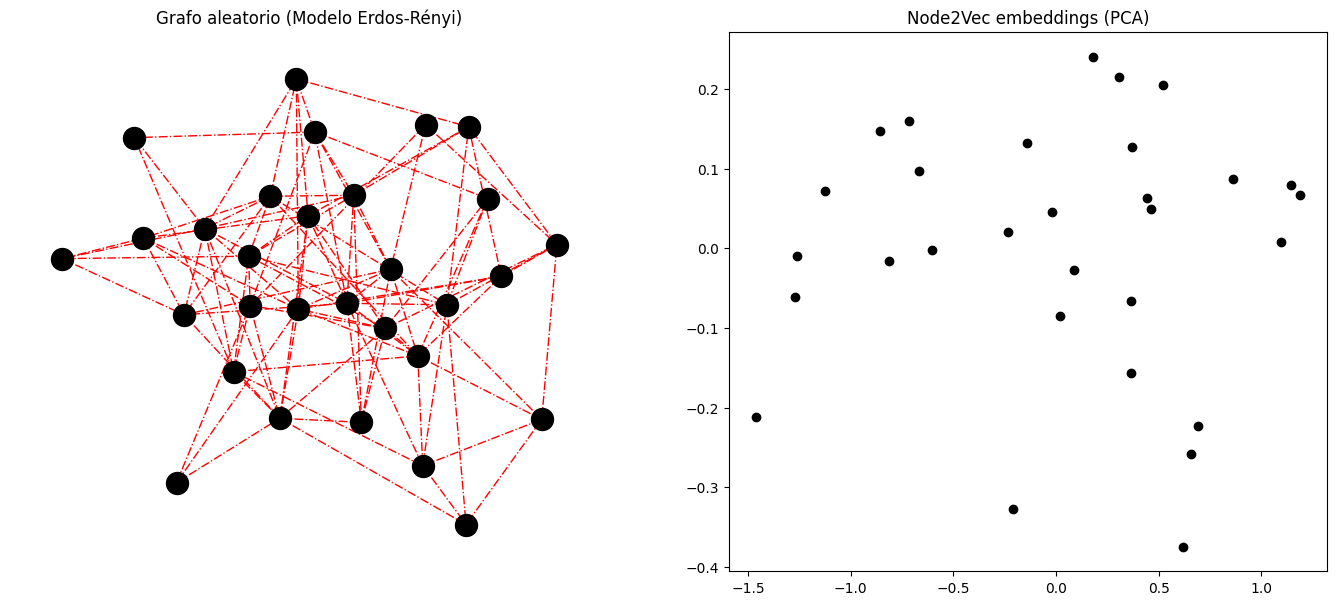

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.029098624363541603
Embeddings max: 0.9248237013816833
Embeddings min: -0.8516097068786621


In [102]:
visualization(g = "e_r")

**BARABASI-ALBERT**

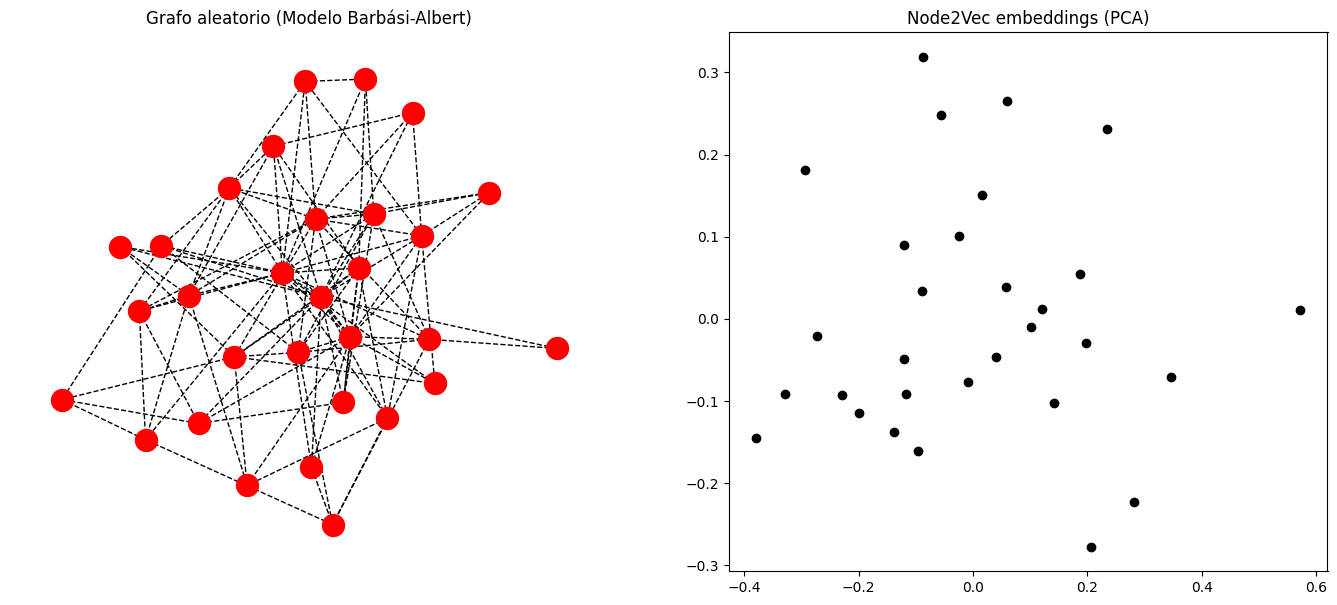

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.019641447812318802
Embeddings max: 0.7934609651565552
Embeddings min: -0.682494580745697


In [105]:
visualization("b_a")

**WATTS-STROGATZ**

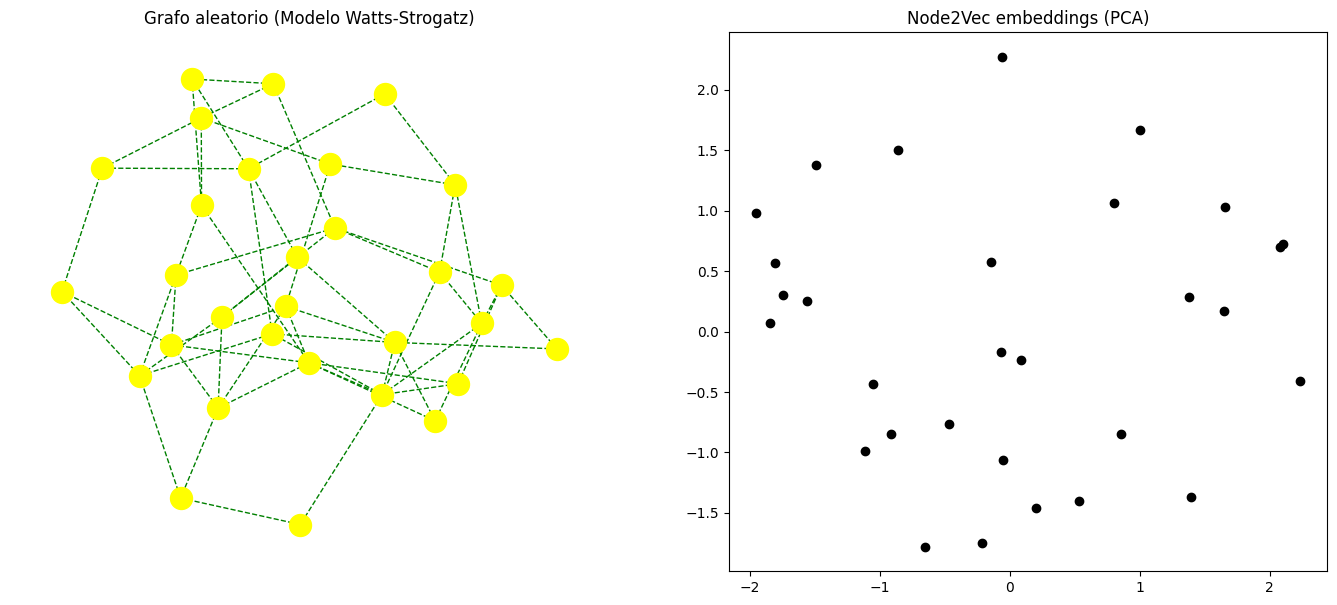

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.03376258164644241
Embeddings max: 1.4890154600143433
Embeddings min: -1.4824455976486206


In [107]:
visualization("w_s")

**RANDOM TREE**

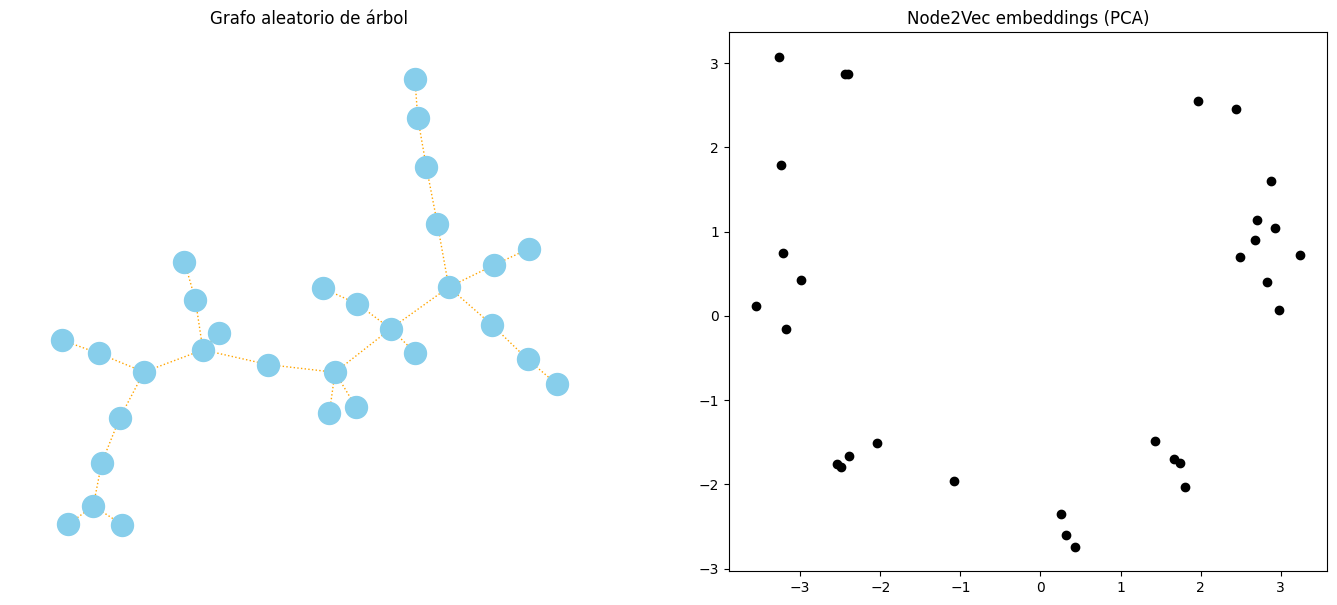

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.04506786912679672
Embeddings max: 2.1006007194519043
Embeddings min: -2.4348020553588867


In [116]:
visualization(g = "r_t")

**STOCHASTIC BLOCK MODEL**

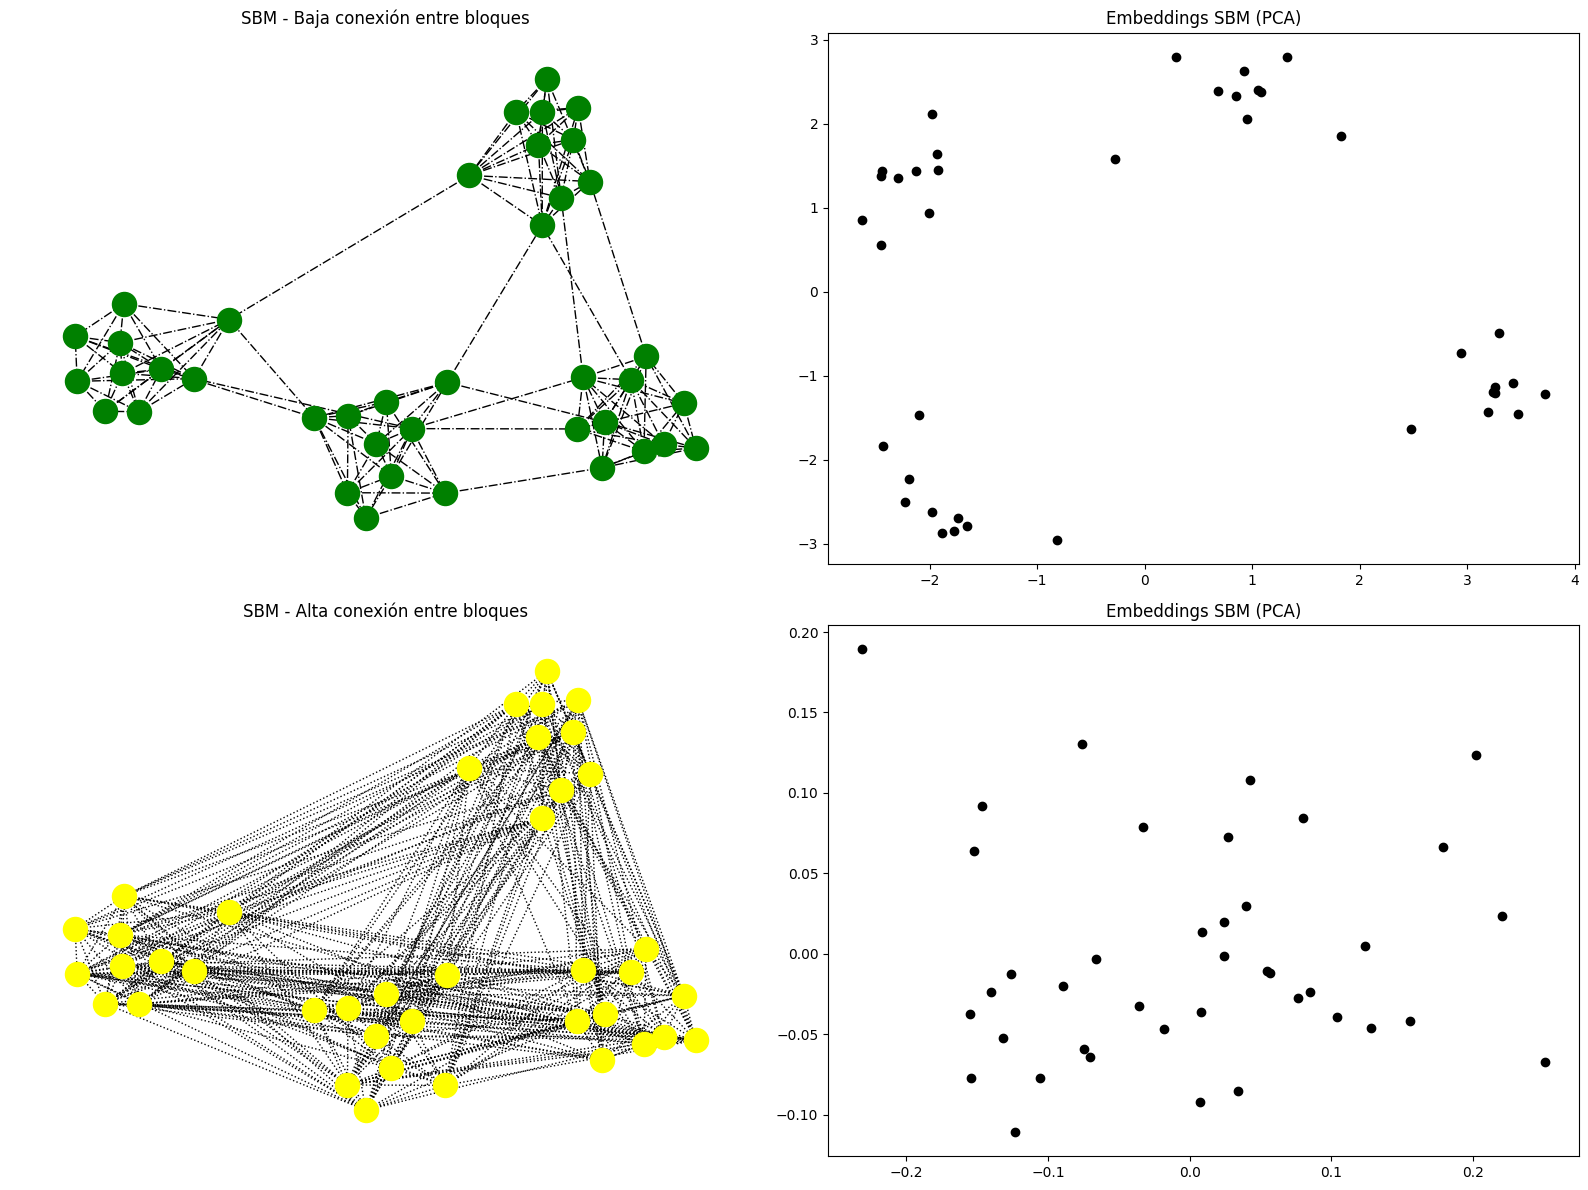

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.012117553502321243
Embeddings max: 2.159261465072632
Embeddings min: -2.5241544246673584


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: 0.019504152238368988
Embeddings max: 0.6849344968795776
Embeddings min: -0.6467291712760925


In [122]:
visualization("SMB")

# Resultados